## Customer Segmentation Using Clustering

### Customer Segmentation

- Customer segmentation is a powerful marketing
strategy. By dividing a broad customer base into smaller groups with similar characteristics, businesses can tailor their marketing efforts more effectively.

- It helps in understanding customer behavior, predicting future purchases, and personalizing products or services.


### What is RFM?

**RFM** stands for **Recency, Frequency, and Monetary Value**, and it's a powerful marketing analysis framework used to identify a company's best customers based on their past purchasing behavior. It segments customers into homogeneous groups, allowing businesses to tailor marketing strategies, improve customer retention, and increase profitability.

**Purpose:**

*   **Customer Segmentation:** Categorize customers into distinct groups based on their transaction history.
*   **Targeted Marketing:** Develop specific marketing campaigns for different customer segments, optimizing resource allocation.
*   **Customer Lifetime Value (CLV) Prediction:** Gain insights into which customers are most valuable and likely to remain so.
*   **Retention Strategies:** Identify at-risk customers and implement strategies to prevent churn.

**The Three Dimensions:**

1.  **Recency (R):** How recently did the customer make a purchase? Customers who purchased more recently are often more responsive to promotions.
2.  **Frequency (F):** How often does the customer make purchases? Customers who buy frequently are generally more engaged and loyal.
3.  **Monetary Value (M):** How much money does the customer spend? Customers who spend more contribute significantly to revenue and are often considered high-value customers.

### What is Recency?

In the RFM (Recency, Frequency, Monetary) model, **Recency** is a crucial metric that measures the time elapsed since a customer's last purchase. It is typically calculated as the number of days between the current date and the date of the customer's most recent transaction.

#### Importance in Customer Engagement:

Recency is highly important for identifying customer engagement and responsiveness. It provides immediate insight into how recently a customer has interacted with the business. Customers who have made a purchase more recently are generally considered more engaged and are often more receptive to marketing campaigns and promotions. They are more likely to remember their last experience with the brand and, therefore, more likely to make another purchase.

#### Interpretation of Recency Values:

A **lower Recency value** (meaning fewer days since the last purchase) indicates **higher customer engagement**. These customers are 'fresh' in their interaction with the business and are often the most valuable segment for immediate marketing efforts, cross-selling, and up-selling. Conversely, a higher Recency value suggests that a customer has not made a purchase in a long time, indicating a potential decrease in engagement or even churn. Monitoring Recency helps businesses identify active customers and re-engage those who might be drifting away.

### What is Frequency ?
In the RFM (Recency, Frequency, Monetary) model, 'Frequency' represents the total number of purchases or orders a customer has made over a specific period. It is a crucial metric for understanding customer engagement and loyalty.

**Significance:**
*   **Identifies Loyal Customers:** Customers with higher frequency are often more loyal and engaged with the business.
*   **Repeat Purchasers:** A high frequency indicates that a customer repeatedly interacts with the business, suggesting satisfaction and a sustained relationship.
*   **Predictive Power:** Frequency can be a strong predictor of future purchasing behavior and customer lifetime value (CLV).

**Interpretation:**
A higher frequency value signifies a more engaged and valuable customer. These customers are not just making one-off purchases but are consistently returning to buy products or services. Businesses often prioritize these high-frequency customers for retention strategies and personalized marketing campaigns, as they represent a stable and reliable revenue stream.


### What is Monetary Value ?

In the context of customer segmentation, particularly within the RFM (Recency, Frequency, Monetary) framework, **Monetary Value** represents the **total amount of money a customer has spent** with the business over a specific period. It is a crucial metric for understanding customer profitability and identifying your most valuable customers.

### Significance of Monetary Value:

*   **Customer Profitability:** A higher monetary value directly indicates a more profitable customer. These customers contribute significantly to the business's revenue and are often essential for sustained growth.

*   **Identifying High-Value Customers:** By analyzing monetary value, businesses can pinpoint their 'whale' customers – those who spend the most. These high-value customers often deserve special attention, personalized offers, and loyalty programs to ensure retention.

*   **Resource Allocation:** Understanding which customers have a high monetary value helps in allocating marketing and sales resources more effectively. Efforts can be focused on retaining and nurturing these top-tier customers, as well as on strategies to encourage other customers to increase their spending.

*   **Predictive Power:** Customers with a history of high spending are often more likely to spend more in the future. Monetary value can be a strong predictor of future purchasing behavior and customer lifetime value (CLTV).

## Dataset Summary

*   The Online Retail Dataset, spanning from 01/12/2010 to 09/12/2011, contains transactional data from a UK-based online retail store.
*   Each entry in the dataset represents a line item from an invoice, detailing product quantity and other transaction specifics.
*   The store primarily sells unique all-occasion gift-wares, with many customers identified as wholesalers.
*   Key features of the dataset include:
    *   `InvoiceNo`: A unique 6-digit identifier for each transaction, where a 'c' prefix indicates a cancellation.
    *   `StockCode`: A unique 5-digit identifier for each distinct product.
    *   `Description`: The name of the product.
    *   `Quantity`: The number of units of a product per transaction.
    *   `InvoiceDate`: The date and time of the transaction.
    *   `UnitPrice`: The price per unit of the product in sterling (£).
    *   `CustomerID`: A unique 5-digit identifier for each customer.
    *   `Country`: The country of residence for the customer.

Reference for dataset:- https://archive.ics.uci.edu/dataset/352/online+retail


In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Loading the data and Cleaning it
retail_data = pd.read_excel("/content/drive/MyDrive/Online_Retail.xlsx")
retail_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Lets start analyzing the data
# checking thr shape like number of rows and columns in the dataset
# So, we have around 500K rows and 8 columns
retail_data.shape

(541909, 8)

In [ ]:
# now lets check the missing data
retail_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Drop missing CustomerIDs
retail_data = retail_data.dropna(subset=['CustomerID'])

retail_data["CustomerID"] = retail_data["CustomerID"].astype(int)

# Remove cancellations (InvoiceNo starting with 'C')
retail_data = retail_data[~retail_data["InvoiceNo"].astype(str).str.startswith('C')]

# Remove negative/zero quantities
retail_data = retail_data[retail_data["Quantity"] > 0]

# Remove zero or negative unit prices (free items or data errors)
retail_data = retail_data[retail_data["UnitPrice"] > 0]

# Creating revenue column
retail_data["Revenue"] = retail_data["Quantity"] * retail_data["UnitPrice"]

In [ ]:
# Lets check the shape of the data
retail_data.shape

(397884, 9)

In [ ]:
# Lets recheck for any missing columns
retail_data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Revenue,0


In [ ]:
retail_data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08


In [ ]:
# Lets Build the RFM features

## Set reference date as day after last transaction
reference_date = retail_data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = retail_data.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("Revenue", "sum")
).reset_index()

In [ ]:
# Lets check the rfm data
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [ ]:
# Description of the RFM data
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [ ]:
# Lets handle the outliers and scale it
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [ ]:
# Scale so all the features are on the same range
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

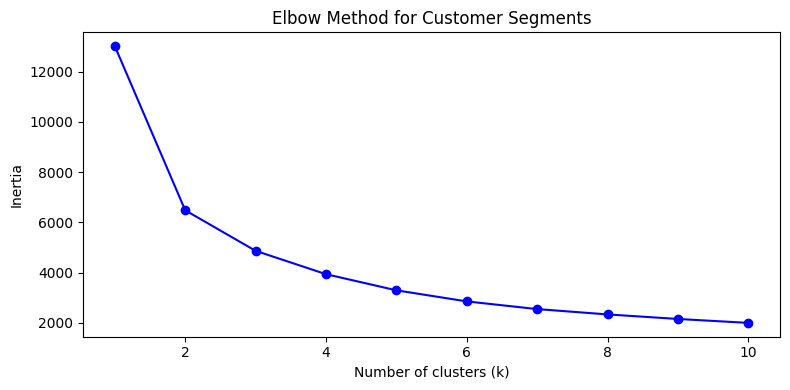

In [ ]:
#  Find the Right Number of Clusters
# Run K-Means for k = 1 through 10, plot inertia against k, look for the elbow. You'll likely see it at k = 3 or k = 4.
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='blue')
plt.title('Elbow Method for Customer Segments')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [ ]:
# Now Lets Run K-Means and label the segments
## Fit K-Means, assign clusters, calculate the average RFM profile per cluster.

## Then interpret:
## Low recency + high spend → Champions
## Low recency + low spend → New customers
## High recency + high spend → At risk
## High recency + low spend → Lost
## The labels will depend on the actual output. That's the point.

# Run with k = 4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm["Cluster"] = rfm['Cluster'].astype(str)

# Get the average profile of each segment
summary = rfm.groupby('Cluster')[["Recency" , "Frequency" , "Monetary"]].mean().round(1)

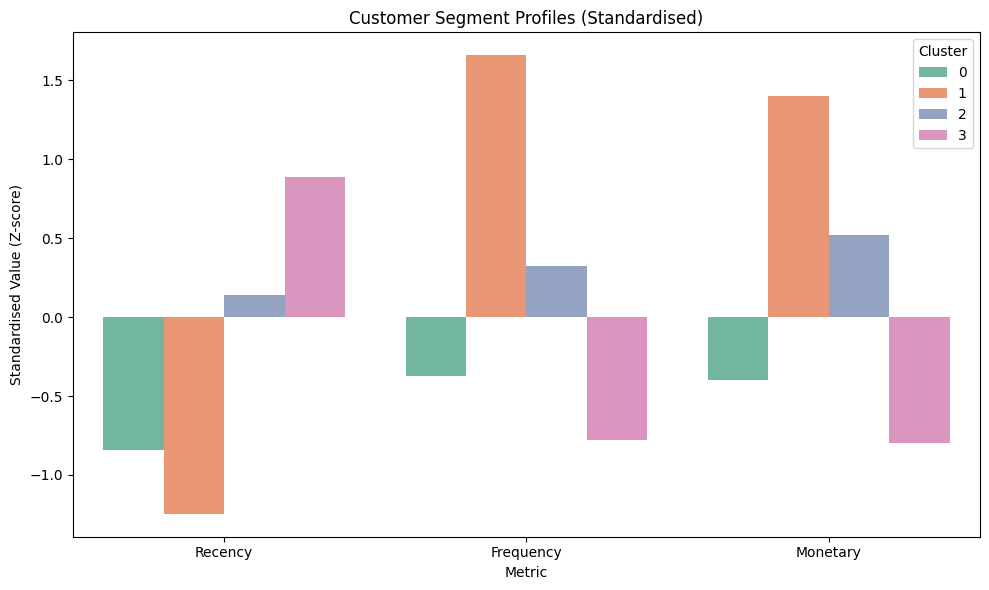

In [ ]:
# Lets interpret the clusters
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])
rfm_scaled_df['Cluster'] = rfm['Cluster'].values

cluster_profile = rfm_scaled_df.groupby('Cluster').mean().reset_index()

rfm_melt = cluster_profile.melt(id_vars=['Cluster'], var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 6))
sns.barplot(data=rfm_melt, x="Metric", y="Value", hue="Cluster", palette="Set2")
plt.title("Customer Segment Profiles (Standardised)")
plt.ylabel("Standardised Value (Z-score)")
plt.tight_layout()
plt.show()

In [ ]:
display(summary)

,Recency,Frequency,Monetary
Cluster,,,
0,18.1,2.1,551.8
1,12.1,13.7,8074.3
2,71.1,4.1,1802.8
3,182.5,1.3,343.5


### Customer Segment Interpretation

After running the K-Means algorithm with 4 clusters and examining the average RFM values for each segment, we can interpret them as follows:

*   **Cluster 1: Champions / Best Customers**
    *   **Recency (12.1 days):** Very low, indicating recent purchases.
    *   **Frequency (13.7 orders):** Very high, showing frequent engagement.
    *   **Monetary (8074.3):** Very high, signifying top spenders.
    *   **Interpretation:** These are your most valuable customers. They buy recently, often, and spend a lot. They should be rewarded and nurtured to maintain their loyalty.

*   **Cluster 0: Loyal Customers / Active Buyers**
    *   **Recency (18.1 days):** Low, indicating fairly recent activity.
    *   **Frequency (2.1 orders):** Medium-low, suggesting more than one-time buyers but not as frequent as champions.
    *   **Monetary (551.8):** Medium-low, reflecting consistent but not exceptionally high spending.
    *   **Interpretation:** These customers are active and show loyalty. They are less frequent and spend less than champions but are still valuable and responsive. They could be targeted with offers to increase frequency or average order value.

*   **Cluster 2: At Risk / Needs Attention**
    *   **Recency (71.1 days):** Medium-high, indicating they haven't purchased in a while.
    *   **Frequency (4.1 orders):** Medium, they used to buy fairly often.
    *   **Monetary (1802.8):** Medium-high, they have spent a good amount historically.
    *   **Interpretation:** These customers were good historically but have become less active. They are 'at risk' of churning. Win-back campaigns or personalized offers could re-engage them before they are lost.

*   **Cluster 3: Lost Customers / Churners**
    *   **Recency (182.5 days):** Very high, meaning a long time since their last purchase.
    *   **Frequency (1.3 orders):** Very low, indicating infrequent purchases.
    *   **Monetary (343.5):** Very low, suggesting minimal spending.
    *   **Interpretation:** These customers have likely churned. It's difficult to re-engage them, and efforts might be better focused on retention of other segments, or very targeted, low-cost re-engagement efforts for this group.

### How the Clusters are Interpreted

Interpreting the clusters involves looking at the average Recency, Frequency, and Monetary values for each cluster (from the `summary` table and the bar plot) and understanding what those values signify in combination. Here's a breakdown of the thought process:

1.  **Analyze the `summary` table:** We start by examining the `summary` DataFrame, which gives us the *mean* Recency, Frequency, and Monetary values for each cluster. For example:

    ```
             Recency  Frequency  Monetary
    Cluster                              
    0           18.1        2.1     551.8
    1           12.1       13.7    8074.3
    2           71.1        4.1    1802.8
    3          182.5        1.3     343.5
    ```

2.  **Compare values across clusters:** We look for patterns and relative differences between the clusters for each RFM metric. We consider what constitutes 'low', 'medium', and 'high' for each metric by comparing the values across the clusters and against the overall dataset's `describe()` output (where relevant).

    *   **Recency:** A *lower* Recency value (e.g., 12.1 days for Cluster 1, 18.1 days for Cluster 0) means the customer purchased more recently, indicating higher engagement. A *higher* Recency (e.g., 182.5 days for Cluster 3, 71.1 days for Cluster 2) means it's been a long time since their last purchase, indicating less engagement or potential churn.

    *   **Frequency:** A *higher* Frequency value (e.g., 13.7 for Cluster 1) means the customer buys more often. A *lower* Frequency (e.g., 1.3 for Cluster 3, 2.1 for Cluster 0) means they buy less often.

    *   **Monetary:** A *higher* Monetary value (e.g., 8074.3 for Cluster 1) means the customer spends more. A *lower* Monetary value (e.g., 343.5 for Cluster 3, 551.8 for Cluster 0) means they spend less.

3.  **Combine RFM scores for segment labels:** Based on these comparisons, we assign descriptive names:

    *   **Cluster 1 (Recency: 12.1, Frequency: 13.7, Monetary: 8074.3):**
        *   **Very Low Recency** (most recent purchase)
        *   **Very High Frequency** (most frequent purchases)
        *   **Very High Monetary** (highest spend)
        *   **Interpretation:** This combination strongly indicates your **Champions** or **Best Customers**.

    *   **Cluster 0 (Recency: 18.1, Frequency: 2.1, Monetary: 551.8):**
        *   **Low Recency** (quite recent)
        *   **Medium-low Frequency** (more than once, but not super often)
        *   **Medium-low Monetary** (consistent but not top spenders)
        *   **Interpretation:** These are still good, **Loyal Customers** or **Active Buyers**.

    *   **Cluster 2 (Recency: 71.1, Frequency: 4.1, Monetary: 1802.8):**
        *   **Medium-High Recency** (hasn't bought in a while)
        *   **Medium Frequency** (used to buy fairly often)
        *   **Medium-High Monetary** (spent a good amount historically)
        *   **Interpretation:** This profile suggests customers who were valuable but are now becoming disengaged – they are **At Risk**.

    *   **Cluster 3 (Recency: 182.5, Frequency: 1.3, Monetary: 343.5):**
        *   **Very High Recency** (very long time since last purchase)
        *   **Very Low Frequency** (infrequent purchases)
        *   **Very Low Monetary** (minimal spend)
        *   **Interpretation:** This profile points to customers who have likely churned – **Lost Customers** or **Churners**.

The standardized bar plot further solidifies these interpretations by visually showing the relative position of each cluster on a common scale for each RFM dimension.